## 1. What this notebook computes

Every notebook of this book is run twice by the book's checking tool, and the
second run must reproduce the first one exactly, byte for byte: the same printed
text, the same pictures, the same files. The Revision record does the same with
its long computations: its solvers of the Kohn-Sham equations were run a second
time and their result files compared byte for byte. This notebook shows, with
small experiments, what could make two runs differ and how the book prevents it.
It

- shows how the computer stores the number 0.1, and why 0.1 + 0.2 is not exactly
  0.3;
- draws the gaps between neighbouring numbers of the computer;
- adds the same numbers in two different orders and draws how the results differ
  in their last digits, which is why checks compare numbers with a tolerance;
- reads the tolerances of the Revision record's Kohn-Sham solver and the
  differences that were measured, and draws them;
- reads the record's negative control, which shows how two runs that round the
  same way hid an error, and draws it;
- shows how a seed makes random numbers repeat exactly;
- runs Python twelve times and shows that the order of a set of names changes from
  run to run, while the sorted order does not;
- shows that line ends change the bytes of a file, counts the result files of the
  Revision record and confirms that none has the line ends of Windows;
- computes the sha256 fingerprints of 582 result files, compares them with the
  fingerprints written down in the record, and reads the record's comparisons of
  two runs of each solver;
- draws six teaching plots and prints a PASS line for every check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 00d (Why every run gives the same bytes: rounding, order, seeds and line ends)
is the file `Revision/textbook/notebooks/00d_reproducible_runs.ipynb` of the repository
Dirac_claude. It shows with small experiments why the notebooks of the textbook print the
same numbers and write the same files every time they run: how the computer rounds
decimal numbers, why the order of a sum changes its last digits (so that checks allow a
tolerance), how a seed fixes random numbers, why names are sorted before they are
printed, and why every file is written with the same line ends. It reproduces the
tolerance, line-end, fingerprint and repeat checks of the Revision Kohn-Sham record
(eight measured differences below their tolerances, a negative control that shows how one
shared rounding path hid an error, 584 result files of two solvers without CR LF line
ends, 582 recorded sha256 fingerprints equal to the files of today, two repeat runs byte
for byte) and draws six teaching plots. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy and matplotlib; the other packages run Jupyter, the program that
shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 00d_reproducible_runs.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 00d_reproducible_runs.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
00d_reproducible_runs.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/00d.captions.json`
- `Revision/textbook/figures/00d_1_float_spacing.png`
- `Revision/textbook/figures/00d_2_summation_order.png`
- `Revision/textbook/figures/00d_3_tolerances.png`
- `Revision/textbook/figures/00d_4_shared_rounding.png`
- `Revision/textbook/figures/00d_5_seeded_walks.png`
- `Revision/textbook/figures/00d_6_set_orders.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the six figure files of this notebook exist
    ALL 22 CHECKS PASSED (notebook 00d)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/00d_reproducible_runs.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "AssertionError: check failed" for a check about the files of the folder
  Revision/kohn_sham (their number, their line ends or their fingerprints): a file of the
  Revision record was changed, added or converted after the repository was downloaded.
  The first command below, run in the repository folder, lists every changed or added
  file; the second restores a changed file (write the file name that the first command
  printed instead of FILE); delete a file that the first command lists as untracked.

      git status
      git restore FILE

- "CalledProcessError" in the section about the order of a set of names: the notebook
  could not start Python a second time. Close JupyterLab, activate the environment again,
  start JupyterLab again from the same terminal and run the notebook again.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 00d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 00d (Why every run gives the same bytes: rounding, order, seeds and line ends)
# is the file Revision/textbook/notebooks/00d_reproducible_runs.ipynb of the repository
# Dirac_claude. It shows with small experiments why the notebooks of the textbook print
# the same numbers and write the same files every time they run: how the computer rounds
# decimal numbers, why the order of a sum changes its last digits (so that checks allow a
# tolerance), how a seed fixes random numbers, why names are sorted before they are
# printed, and why every file is written with the same line ends. It reproduces the
# tolerance, line-end, fingerprint and repeat checks of the Revision Kohn-Sham record
# (eight measured differences below their tolerances, a negative control that shows how
# one shared rounding path hid an error, 584 result files of two solvers without CR LF
# line ends, 582 recorded sha256 fingerprints equal to the files of today, two repeat
# runs byte for byte) and draws six teaching plots. It needs a computer with Windows 11,
# macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 00d_reproducible_runs.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 00d_reproducible_runs.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 00d_reproducible_runs.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/00d.captions.json
# - Revision/textbook/figures/00d_1_float_spacing.png
# - Revision/textbook/figures/00d_2_summation_order.png
# - Revision/textbook/figures/00d_3_tolerances.png
# - Revision/textbook/figures/00d_4_shared_rounding.png
# - Revision/textbook/figures/00d_5_seeded_walks.png
# - Revision/textbook/figures/00d_6_set_orders.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the six figure files of this notebook exist
#     ALL 22 CHECKS PASSED (notebook 00d)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/00d_reproducible_runs.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "AssertionError: check failed" for a check about the files of the folder
#   Revision/kohn_sham (their number, their line ends or their fingerprints): a file of
#   the Revision record was changed, added or converted after the repository was
#   downloaded. The first command below, run in the repository folder, lists every
#   changed or added file; the second restores a changed file (write the file name that
#   the first command printed instead of FILE); delete a file that the first command
#   lists as untracked.
#     git status
#     git restore FILE
# - "CalledProcessError" in the section about the order of a set of names: the notebook
#   could not start Python a second time. Close JupyterLab, activate the environment
#   again, start JupyterLab again from the same terminal and run the notebook again.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "00d"  # this notebook: chapter 00, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 00d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Bit, byte**: a bit is one binary digit, 0 or 1; a byte is 8 bits, a whole
  number from 0 to 255. Every file is a sequence of bytes.
- **Binary**: the way of writing numbers with the two digits 0 and 1, in powers of
  2 instead of powers of 10: binary 101 is $4 + 0 + 1 = 5$, and binary 0.11 is
  $1/2 + 1/4 = 3/4$.
- **Floating-point number**: the way the computer stores a number with a fraction
  part: a whole number of at most 53 binary digits times a power of 2. Python's
  `float` and numpy's `float64` are such numbers. They have about 16 significant
  decimal digits.
- **Rounding**: replacing a number by the nearest floating-point number. It happens
  after every addition, multiplication and division.
- **Gap, unit in the last place (ulp)**: the distance from a floating-point number
  to the next larger one. A difference of one ulp is the smallest possible change
  of a stored number.
- **Machine epsilon** $\epsilon$: the gap between 1 and the next larger
  floating-point number, $\epsilon = 2^{-52} \approx 2.22 \times 10^{-16}$.
- **Tolerance**: the largest difference between two numbers that a check accepts
  as agreement.
- **Random-number generator, seed**: a program that produces numbers that look
  random. It starts from a number called the *seed*; the same seed always gives the
  same sequence.
- **Random walk**: a path that takes a step of $+1$ or $-1$ at random, again and
  again.
- **Set**: an unordered collection of different things, written `{"x1", "x2"}` in
  Python. Python keeps the names of a set in an order decided by their *hash
  values*: numbers computed from the names with a secret key that Python chooses
  anew each time it starts, unless the *environment variable* PYTHONHASHSEED fixes
  the key.
- **Environment variable**: a named setting that a program receives from the
  computer when it starts.
- **Line end**: the bytes that end a line of a text file. Linux and macOS use one
  byte, LF (line feed, the number 10); Windows traditionally uses two, CR LF
  (carriage return 13, then line feed 10).
- **Fingerprint (sha256)**: 64 hexadecimal characters computed from the bytes of a
  file; a file that differs in a single byte gives a completely different
  fingerprint. **Hexadecimal**: the digits 0 to 9 and the letters a to f.
- **Manifest**: a file that lists other files with their fingerprints.
- **Byte-identical**: two files with exactly the same bytes.
- **Subprocess**: a program that another program starts and whose printed output it
  reads.

## 4. The physical and mathematical situation

A computer is deterministic: given the same program and the same input, it does the
same steps and gets the same result. Yet two runs of a careless notebook can print
different text, for five reasons:

1. it prints the time or the date;
2. it uses random numbers without a fixed seed;
3. it prints the names of a set, or of the files of a folder, in an order that can
   change from run to run;
4. it adds numbers in an order that depends on the computer (for example on the
   number of processor cores working together), and the order changes the last
   digits of a sum;
5. it writes files with the line ends of the operating system.

The notebooks of the book avoid all five: they print no times, use fixed seeds,
sort names before printing them, add in a fixed order, and write every file with
LF line ends. Where two *different* computations of the same quantity are compared,
for example two solvers or two step sizes, the results agree only up to rounding
and up to the errors of the methods; such a comparison uses a tolerance that is
fixed before the comparison is made.

Why does rounding exist at all? A decimal fraction such as $0.1 = 1/10$ has a power
of 10 below the fraction line. The computer stores binary fractions, which have a
power of 2 below the fraction line. Since $10 = 2 \cdot 5$, the factor 5 cannot be
removed, and $1/10$ is not a binary fraction: its binary expansion
$0.000110011001100\ldots$ never ends, just as $1/3 = 0.333\ldots$ never ends in
decimal. The computer keeps 53 significant binary digits and rounds the rest away;
it stores 0.1 as the nearest binary fraction,
$$0.1 \approx \frac{3602879701896397}{2^{55}} = 0.1000000000000000055511\ldots$$
Every further operation rounds its result again to 53 binary digits. Rounding is
deterministic (the same operation on the same numbers always gives the same
result), but it depends on the order of the operations: in general
$(a + b) + c$ and $a + (b + c)$ round differently.

## 5. How the computer stores 0.1

The next cell imports two modules of Python itself. `Fraction(x)` writes the
floating-point number $x$ as the exact fraction that the computer stores, and
`Decimal(x)` writes all its decimal digits. The cell prints both for 0.1, prints
$0.1 + 0.2$ with every digit that Python needs to identify the stored number
(`!r` inside the braces of an f-string asks for this), and checks two facts: 0.1 is
stored as $3602879701896397 / 2^{55}$, and $0.1 + 0.2$ differs from $0.3$ by
$2^{-54} \approx 5.55 \times 10^{-17}$.

The cell also defines the helper `check_reproduces`, used later for checks that
reproduce a Revision record: it first calls `sys.stdout.flush()`, which sends all
printed text that is still waiting, and then calls `check` with the record.
(Jupyter sends printed text in pieces; flushing first keeps the PASS line and the
line `reproduces ...` below it in one piece, so that the book's tools read them
together.)

In [2]:
import sys  # sys.stdout is the channel through which the notebook prints
from decimal import Decimal  # the exact decimal digits of a stored number
from fractions import Fraction  # a stored number as an exact fraction

import numpy as np  # arrays of numbers


def check_reproduces(condition, name, record):
    """check(condition, name, record=record), after sending the waiting output."""
    sys.stdout.flush()  # send every printed line that is still waiting
    check(condition, name, record=record)


stored = Fraction(0.1)  # the fraction that the computer really stores for 0.1
say(f"0.1 is stored as the fraction {stored}")
say(f"    = {Decimal(0.1)}")
say(f"0.1 + 0.2 = {0.1 + 0.2!r}")
say(f"0.1 + 0.2 == 0.3 is {0.1 + 0.2 == 0.3}")  # == asks: exactly equal?
difference = (0.1 + 0.2) - 0.3
report("(0.1 + 0.2) - 0.3", repr(difference))
check(stored == Fraction(3602879701896397, 2 ** 55),
      "0.1 is stored as 3602879701896397 / 2^55, not exactly as 1/10")
check(0.1 + 0.2 != 0.3 and difference == 2.0 ** -54,
      "0.1 + 0.2 differs from 0.3 by 2^-54 = 5.55e-17, one rounding step")

0.1 is stored as the fraction 3602879701896397/36028797018963968
    = 0.1000000000000000055511151231257827021181583404541015625
0.1 + 0.2 = 0.30000000000000004
0.1 + 0.2 == 0.3 is False
RESULT (0.1 + 0.2) - 0.3 = 5.551115123125783e-17
PASS 0.1 is stored as 3602879701896397 / 2^55, not exactly as 1/10
PASS 0.1 + 0.2 differs from 0.3 by 2^-54 = 5.55e-17, one rounding step


The next cell asks numpy for the machine epsilon $\epsilon$ of 64-bit
floating-point numbers, the gap between 1 and the next larger stored number. It
checks that $\epsilon = 2^{-52}$, that $1 + \epsilon$ is stored as a number larger
than 1, and that $1 + \epsilon/2$, which lies exactly halfway between 1 and
$1 + \epsilon$, is rounded back to 1. (A number exactly halfway is rounded to the
neighbour whose last binary digit is 0, which here is 1.)

In [3]:
epsilon = float(np.finfo(np.float64).eps)  # the gap between 1 and the next number
report("machine epsilon", repr(epsilon))
say(f"1 + epsilon     == 1 is {1.0 + epsilon == 1.0}")
say(f"1 + epsilon / 2 == 1 is {1.0 + epsilon / 2 == 1.0}")
check(epsilon == 2.0 ** -52 and 1.0 + epsilon > 1.0 and 1.0 + epsilon / 2 == 1.0,
      "machine epsilon is 2^-52: 1 + 2^-52 is stored, 1 + 2^-53 rounds back to 1")

RESULT machine epsilon = 2.220446049250313e-16
1 + epsilon     == 1 is False
1 + epsilon / 2 == 1 is True
PASS machine epsilon is 2^-52: 1 + 2^-52 is stored, 1 + 2^-53 rounds back to 1


## 6. The gaps between neighbouring numbers

The gap between neighbouring floating-point numbers is not the same everywhere: it
grows with the size of the numbers. Between $2^{k}$ and $2^{k+1}$ all stored
numbers have the same gap $2^{k - 52}$, and the gap doubles at every power of 2. So
for every $x$ the gap lies between $\epsilon x / 2$ and $\epsilon x$: every stored
number is accurate to about 16 significant digits, whatever its size.

The next cell computes the gap with `np.spacing(x)` at 3000 values of $x$ from
$10^{-3}$ to $10^{6}$ (`np.logspace(-3, 6, 3000)` makes numbers equally spaced on
a logarithmic axis), draws it on logarithmic axes together with the two lines
$\epsilon x$ and $\epsilon x / 2$, prints the gaps at 1, 1000 and $10^{6}$, and
checks that the gap lies between the two lines at all 3000 points.

gap above         1: 2.220e-16
gap above      1000: 1.137e-13
gap above     1e+06: 1.164e-10


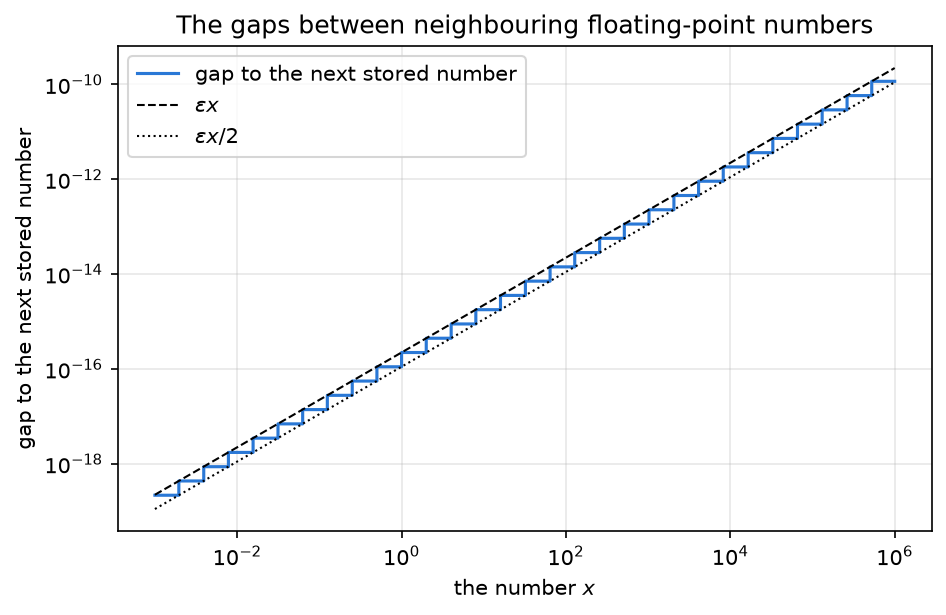

Figure 00d.1 saved as Revision/textbook/figures/00d_1_float_spacing.png
PASS the gap lies between eps x / 2 and eps x at all 3000 points


In [4]:
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
x_values = np.logspace(-3.0, 6.0, 3000)  # 3000 numbers from 0.001 to 1000000
gaps = np.spacing(x_values)  # the gap from each number to the next larger one
for x in (1.0, 1000.0, 1.0e6):
    say(f"gap above {x:>9g}: {np.spacing(x):.3e}")

fig, ax = plt.subplots()
# drawstyle="steps-post" draws each value as a flat step until the next x.
ax.plot(x_values, gaps, color=BLUE, linewidth=1.5, drawstyle="steps-post",
        label="gap to the next stored number")
ax.plot(x_values, epsilon * x_values, color="black", linestyle="--",
        linewidth=1.0, label=r"$\epsilon x$")
ax.plot(x_values, epsilon * x_values / 2, color="black", linestyle=":",
        linewidth=1.0, label=r"$\epsilon x / 2$")
ax.set_xscale("log")  # logarithmic horizontal axis
ax.set_yscale("log")  # logarithmic vertical axis
ax.set_xlabel(r"the number $x$")
ax.set_ylabel("gap to the next stored number")
ax.set_title("The gaps between neighbouring floating-point numbers")
ax.legend(loc="upper left")
save_figure(fig, "float_spacing",
            r"The gap between a floating-point number $x$ and the next larger "
            r"stored number (blue staircase) for $x$ from $10^{-3}$ to $10^{6}$, on "
            r"logarithmic axes (both pure numbers), with the lines $\epsilon x$ "
            r"(dashed) and $\epsilon x/2$ (dotted), $\epsilon = 2^{-52}$. The gap is "
            r"constant between two powers of 2 and doubles at each of them, so it "
            r"always lies between the two lines: every stored number carries about "
            r"16 significant digits, whatever its size.")
ratios = gaps / x_values  # the gap relative to the number
check(bool(np.all(ratios > epsilon / 2) and np.all(ratios <= epsilon))
      and np.spacing(1.0) == epsilon,
      "the gap lies between eps x / 2 and eps x at all 3000 points")

## 7. The order of a sum changes the last digits

We add the numbers $1, 1/4, 1/9, \ldots, 1/N^2$, that is $1/k^2$ for
$k = 1, \ldots, N$, in two orders:

- **forwards**: starting with the largest number 1. The running total is about
  1.6 from the start, so every small number is added to a large total, and each
  addition rounds to the gap of that total;
- **backwards**: starting with the smallest number $1/N^2$. The running total grows
  slowly, and small numbers are added to small totals, which loses less.

The reference is `math.fsum`, which adds the stored numbers exactly and rounds only
once at the end (the *exactly rounded* sum). The difference of each sum from it is
measured in ulps: the difference divided by the gap `np.spacing` of the exact sum.
`np.add.accumulate(terms)` adds the numbers of an array one after the other,
starting with the first, and returns every running total, so `forward[N - 1]` is
the forward sum of the first $N$ numbers. `terms[:N][::-1]` is the first $N$
numbers in reverse order. A third way, numpy's `np.sum`, adds in pairs, then pairs
of pairs, and so on (*pairwise summation*), which also loses little.

The next cell does this for 31 values of $N$ from 10 to $10^{6}$, prints the four
sums for $N = 10^{6}$ with all their digits, and prints how far the sum of $10^{6}$
numbers lies below the limit of the infinite sum, $\pi^2/6$. That last difference,
about $1/N = 10^{-6}$, is not a rounding error: it is the error of the *method*
(stopping after $N$ numbers), and it is about $10^{8}$ times larger than the
rounding differences.

In [5]:
import math  # math.fsum: the exactly rounded sum; math.pi

N_MAX = 10 ** 6
k = np.arange(1, N_MAX + 1, dtype=np.float64)  # 1, 2, ..., 1000000 as floats
terms = 1.0 / (k * k)  # the numbers 1/k^2
forward = np.add.accumulate(terms)  # all forward running totals
# 31 values of N, equally spaced on a logarithmic axis from 10 to 10^6.
n_values = np.unique(np.round(np.logspace(1.0, 6.0, 31)).astype(int))
ulps = {"forward": [], "backward": [], "pairwise": []}  # the errors in ulps
for n in n_values:
    exact = math.fsum(terms[:n])  # the exactly rounded sum of the first n numbers
    gap = np.spacing(exact)  # one ulp of the exact sum
    backward = np.add.accumulate(terms[:n][::-1])[-1]  # smallest number first
    ulps["forward"].append(float((forward[n - 1] - exact) / gap))
    ulps["backward"].append(float((backward - exact) / gap))
    ulps["pairwise"].append(float((np.sum(terms[:n]) - exact) / gap))

# The three sums of all 10^6 numbers, as plain Python floats (float(...)).
forward_million = float(forward[-1])
backward_million = float(np.add.accumulate(terms[::-1])[-1])
pairwise_million = float(np.sum(terms))
exact_million = math.fsum(terms)
say(f"forward  sum of 10^6 numbers: {forward_million!r}")
say(f"backward sum of 10^6 numbers: {backward_million!r}")
say(f"pairwise sum of 10^6 numbers: {pairwise_million!r}")
say(f"exactly rounded sum         : {exact_million!r}")
worst_forward = max(abs(u) for u in ulps["forward"])  # the largest size of error
worst_backward = max(abs(u) for u in ulps["backward"])
worst_pairwise = max(abs(u) for u in ulps["pairwise"])
report("largest forward error in ulps", f"{worst_forward:.0f}")
report("largest backward error in ulps", f"{worst_backward:.0f}")
report("largest pairwise error in ulps", f"{worst_pairwise:.0f}")
report("pi^2/6 minus the exact sum of 10^6 numbers",
       f"{math.pi ** 2 / 6 - exact_million:.6e}")

forward  sum of 10^6 numbers: 1.64493306684877
backward sum of 10^6 numbers: 1.6449330668487263
pairwise sum of 10^6 numbers: 1.6449330668487263
exactly rounded sum         : 1.6449330668487265
RESULT largest forward error in ulps = 196
RESULT largest backward error in ulps = 1
RESULT largest pairwise error in ulps = 3
RESULT pi^2/6 minus the exact sum of 10^6 numbers = 9.999995e-07


The next cell draws the three errors in ulps against $N$ and checks three
statements: the forward and the backward sum of the $10^{6}$ numbers are different
stored numbers (the order matters); the backward sum is never more than one ulp
from the exactly rounded sum; and all three ways agree with the exactly rounded sum
to a relative difference below $10^{-13}$, so a check with the tolerance
$10^{-12}$ accepts each of them.

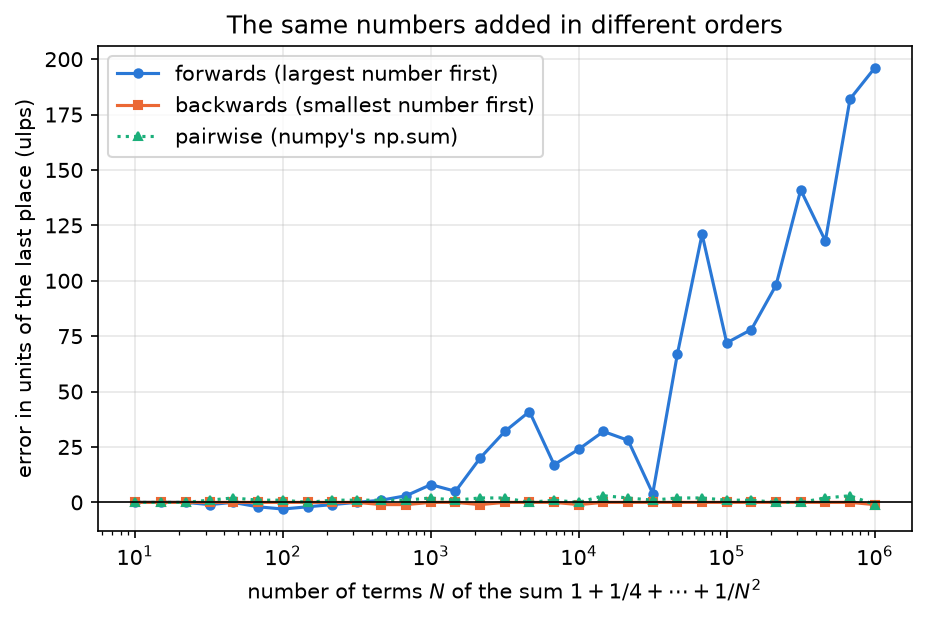

Figure 00d.2 saved as Revision/textbook/figures/00d_2_summation_order.png
RESULT largest relative difference of the three sums of 10^6 numbers = 2.65e-14
PASS forwards and backwards, the sums of the 10^6 numbers differ in the last digits
PASS the backward sum is within one ulp of the exactly rounded sum for every N
PASS the three sums agree to a relative 1e-13: a tolerance of 1e-12 accepts all


In [6]:
fig, ax = plt.subplots()
ax.plot(n_values, ulps["forward"], "o-", color=BLUE, markersize=4,
        label="forwards (largest number first)")
ax.plot(n_values, ulps["backward"], "s-", color=ORANGE, markersize=4,
        label="backwards (smallest number first)")
ax.plot(n_values, ulps["pairwise"], "^:", color=AQUA, markersize=4,
        label="pairwise (numpy's np.sum)")
ax.axhline(0.0, color="black", linewidth=0.8)  # the exactly rounded sum
ax.set_xscale("log")
ax.set_xlabel(r"number of terms $N$ of the sum $1 + 1/4 + \cdots + 1/N^2$")
ax.set_ylabel("error in units of the last place (ulps)")
ax.set_title("The same numbers added in different orders")
ax.legend(loc="upper left")
save_figure(fig, "summation_order",
            r"The rounding error of the sum $1 + 1/4 + 1/9 + \cdots + 1/N^2$ in "
            r"units of the last place (vertical axis, ulps, the gap between "
            r"neighbouring stored numbers at the sum) against the number of terms "
            r"$N$ from 10 to $10^{6}$ (horizontal axis, logarithmic), measured from "
            r"the exactly rounded sum: forwards with the largest term first (blue "
            r"circles), backwards with the smallest term first (orange squares), "
            r"and pairwise as numpy adds (aqua triangles). The forward error grows "
            f"to {worst_forward:.0f} ulps, a relative error of a few times "
            r"$10^{-14}$; the backward error stays within "
            f"{worst_backward:.0f} ulp and the pairwise error within "
            f"{worst_pairwise:.0f} ulps. Same numbers, different order, different "
            r"last digits.")
relative = max(abs(s - exact_million) for s in
               (forward_million, backward_million, pairwise_million)) / exact_million
report("largest relative difference of the three sums of 10^6 numbers",
       f"{relative:.2e}")
check(forward_million != backward_million,
      "forwards and backwards, the sums of the 10^6 numbers differ in the last digits")
check(worst_backward <= 1.0,
      "the backward sum is within one ulp of the exactly rounded sum for every N")
check(relative < 1e-13,
      "the three sums agree to a relative 1e-13: a tolerance of 1e-12 accepts all")

## 8. Why checks allow a tolerance: the Revision record

The Revision record's Kohn-Sham solver, a Rust program, was run with its canonical
settings and again with *refined* settings: twice as many steps of its
Runge-Kutta integrator, root and self-consistency tolerances ten times smaller, and
one equation (the condition that fixes the chemical potential $\mu$) solved in a
different but exactly equivalent form, which rounds along a different path. The
differences between the two runs measure the error of the canonical run. Before the
comparison, tolerances were fixed: $10^{-8}$ for energies, levels and thermodynamic
quantities, $10^{-6}$ for profiles and derivatives.

The report Revision/kohn_sham/reports/ks-rust-determinism.json records eight such
comparisons, each with its tolerance at the end of its detail text, and the
cross-check report Revision/kohn_sham/reports/ks-crosscheck.json quotes the eight
measured largest differences as numbers under the key
`rust_matrix_wide_uncertainties`. The next cell reads both, finds each measured
number (written with four significant digits) in the detail of its check, reads the
tolerance with the pattern `tolerance (\S+)` of the module `re` (`\S+` means one or
more characters that are not blanks; the brackets mark the part to return), and
prints a table with the *margin*, the tolerance divided by the measured
difference. The names of the eight quantities are explained in the Kohn-Sham
chapters; here only their sizes matter.

In [7]:
import re  # finds patterns in texts ("regular expressions")


def read_json(path):
    """The content of the JSON file path of the repository (dictionaries, lists)."""
    return json.loads(repository_file(path).read_text(encoding="utf-8"))


DETERMINISM = "Revision/kohn_sham/reports/ks-rust-determinism.json"
CROSS = "Revision/kohn_sham/reports/ks-crosscheck.json"
determinism_checks = {entry["name"]: entry for entry in read_json(DETERMINISM)["checks"]}
measured = read_json(CROSS)["rust_matrix_wide_uncertainties"]  # name -> difference
SHORT_NAMES = {  # the check names of the record -> short names for the table
    "refined_ground_energies": "ground-state energies",
    "refined_ground_homo_lumo_gap": "level gaps",
    "refined_eigenvalues": "all Kohn-Sham levels",
    "refined_delta_scf": "excitation energies",
    "refined_profiles": "profiles",
    "refined_adiabatic_derivatives": "adiabatic derivatives",
    "refined_thermodynamics": "thermodynamics",
    "refined_heat_capacity": "heat capacity",
}
tolerances, quoted, verdicts = {}, {}, {}
say("quantity                measured   tolerance   margin")
for name, short in SHORT_NAMES.items():
    detail = determinism_checks[name]["detail"]
    verdicts[name] = determinism_checks[name]["verdict"]
    tolerances[name] = float(re.findall(r"tolerance (\S+)", detail)[-1])
    quoted[name] = f"{measured[name]:.3e}" in detail  # the same number in both files
    margin = tolerances[name] / measured[name]
    say(f"{short:22} {measured[name]:9.3e}   {tolerances[name]:9.0e}   {margin:7.1f}")
smallest = min(tolerances[n] / measured[n] for n in SHORT_NAMES)
report("smallest margin (tolerance / measured difference)", f"{smallest:.1f}")
check_reproduces(
    sorted(measured) == sorted(SHORT_NAMES) and all(quoted.values())
    and all(verdicts[n] == "PASS" and measured[n] < tolerances[n] for n in SHORT_NAMES),
    "each of the eight measured differences of the record is below its tolerance",
    f"{DETERMINISM}, checks refined_ground_energies to refined_heat_capacity")

quantity                measured   tolerance   margin
ground-state energies  1.901e-12       1e-08    5260.4
level gaps             1.300e-12       1e-08    7692.3
all Kohn-Sham levels   2.135e-09       1e-08       4.7
excitation energies    5.815e-11       1e-08     172.0
profiles               2.800e-09       1e-06     357.1
adiabatic derivatives  9.024e-10       1e-06    1108.2
thermodynamics         2.489e-10       1e-08      40.2
heat capacity          5.689e-09       1e-06     175.8
RESULT smallest margin (tolerance / measured difference) = 4.7
PASS each of the eight measured differences of the record is below its tolerance
     reproduces Revision/kohn_sham/reports/ks-rust-determinism.json, checks
    refined_ground_energies to refined_heat_capacity


The next cell draws the table: for each of the eight quantities a dot at the
measured difference and a vertical bar at its tolerance, joined by a grey line
whose length on the logarithmic axis is the margin.

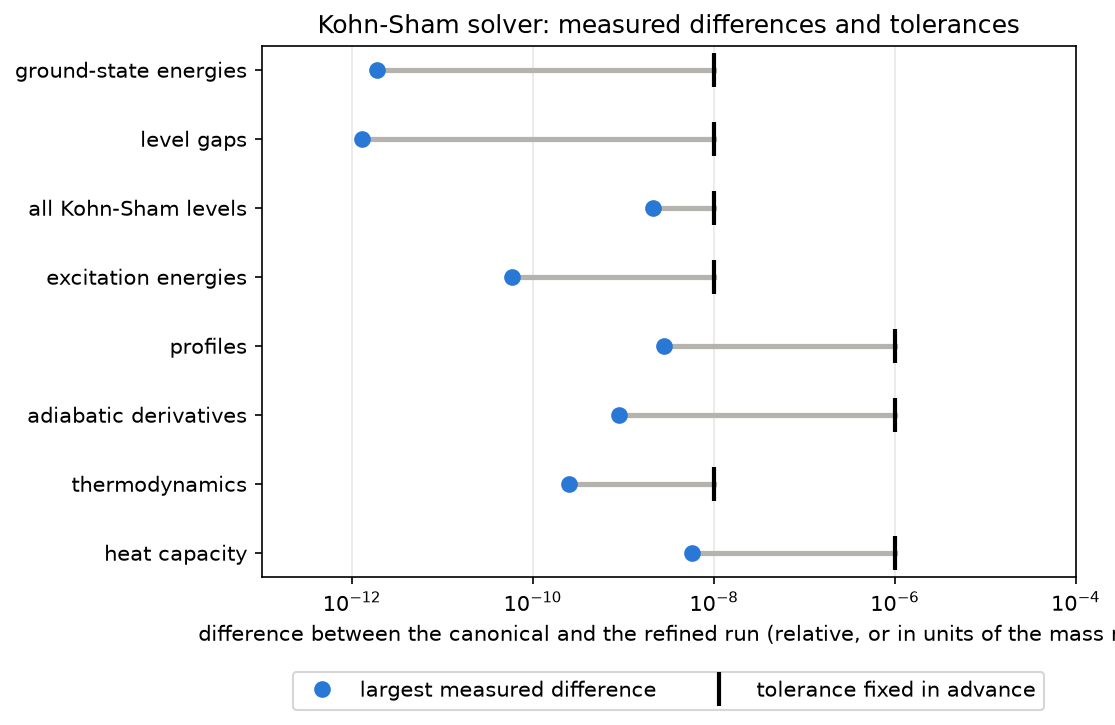

Figure 00d.3 saved as Revision/textbook/figures/00d_3_tolerances.png


In [8]:
fig, ax = plt.subplots(figsize=(7.0, 4.6))
rows = np.arange(len(SHORT_NAMES))[::-1]  # the first quantity at the top
for row, name in zip(rows, SHORT_NAMES):
    ax.plot([measured[name], tolerances[name]], [row, row], color="#b5b3ad",
            linewidth=2.5)  # the margin
ax.plot([measured[n] for n in SHORT_NAMES], rows, "o", color=BLUE, markersize=7,
        label="largest measured difference")
ax.plot([tolerances[n] for n in SHORT_NAMES], rows, "|", color="black",
        markersize=16, markeredgewidth=2.0, label="tolerance fixed in advance")
ax.set_xscale("log")
ax.set_xlim(1e-13, 1e-4)
ax.set_yticks(rows, labels=list(SHORT_NAMES.values()))
ax.grid(False, axis="y")
ax.set_xlabel("difference between the canonical and the refined run "
              "(relative, or in units of the mass m)")
ax.set_title("Kohn-Sham solver: measured differences and tolerances")
# The legend below the picture, in two columns, so that it covers no row.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
margins = [tolerances[n] / measured[n] for n in SHORT_NAMES]  # tolerance / measured
save_figure(fig, "tolerances",
            r"The eight comparisons between the canonical and the refined run of "
            r"the Revision record's Kohn-Sham solver (one row each): the largest "
            r"measured difference (blue dot) and the tolerance fixed before the "
            r"comparison (black bar), on a logarithmic horizontal axis (relative "
            r"differences, or level differences in units of the mass $m$). Every "
            r"dot lies to the left of its bar: the measured differences are "
            f"between {min(margins):.1f} and {max(margins):.0f} times smaller "
            r"than their tolerances. The grey line from a dot to its bar is this "
            r"margin.")

The record also teaches why the refined run had to round along a different path.
An earlier version of the solver found $\mu$ with a third method, a *direct count*,
and used it in BOTH runs. In three thermal states that method was wrong by up to
about $8 \times 10^{-10}\,m$, but both runs made the same rounding error, so the
difference between the runs (the *former measure*) was tiny and hid the error. The
present refined run finds $\mu$ along another rounding path, and its difference
from the old result (the *present measure*) shows the error in full. The check
`refined_mermin_root_path` of the same report records this as a *negative control*
(a test that must detect a known error) in its detail text, one entry per state.

The next cell reads these entries with a regular expression: `re.findall` returns,
for every place where the pattern matches, the parts in brackets (the name of the
state and three numbers). It prints them as a table and checks, as the record
states, that in every state the former measure stays below half of the error while
the present measure is at least half of it. Two computations that make the same
rounding error agree with each other and can still both be wrong: a comparison is
only as good as the independence of the two computations.

In [9]:
root_path = determinism_checks["refined_mermin_root_path"]  # the record's check
CONTROL = (r"(N\w+): direct-count error (\S+) m \(refined run \S+\), "
           r"former measure (\S+), present measure against it (\S+),")
control = []  # (state, error of the old root, former measure, present measure)
for state, error, former, present in re.findall(CONTROL, root_path["detail"]):
    control.append((state, abs(float(error)), float(former), float(present)))
say("state              error of the old   former measure   present measure")
for state, error, former, present in control:
    say(f"{state:17} {error:12.3e} m   {former:14.3e}   {present:15.3e}")
largest_hidden = max(error for _, error, _, _ in control)
report("largest error that one shared rounding path hid", f"{largest_hidden:.3e}", "m")
check_reproduces(
    root_path["verdict"] == "PASS" and len(control) == 3
    and all(former < error / 2 <= present for _, error, former, present in control),
    f"one shared rounding path hid errors up to {largest_hidden:.1e} m; "
    "two paths show them",
    f"{DETERMINISM}, check refined_mermin_root_path")

state              error of the old   former measure   present measure
N8_lamm1_a00_T10     8.267e-10 m        5.829e-16         8.271e-10
N8_lam0_a00_T10      2.722e-10 m        7.528e-13         2.719e-10
N8_lamp1_a00_T10     6.959e-11 m        7.518e-13         6.921e-11
RESULT largest error that one shared rounding path hid = 8.267e-10 m
PASS one shared rounding path hid errors up to 8.3e-10 m; two paths show them
     reproduces Revision/kohn_sham/reports/ks-rust-determinism.json, check
    refined_mermin_root_path


The next cell draws the three states of the negative control: for each state, the
error of the old method, the difference that the former comparison saw, and the
difference that the present comparison sees, as bars on a logarithmic axis.

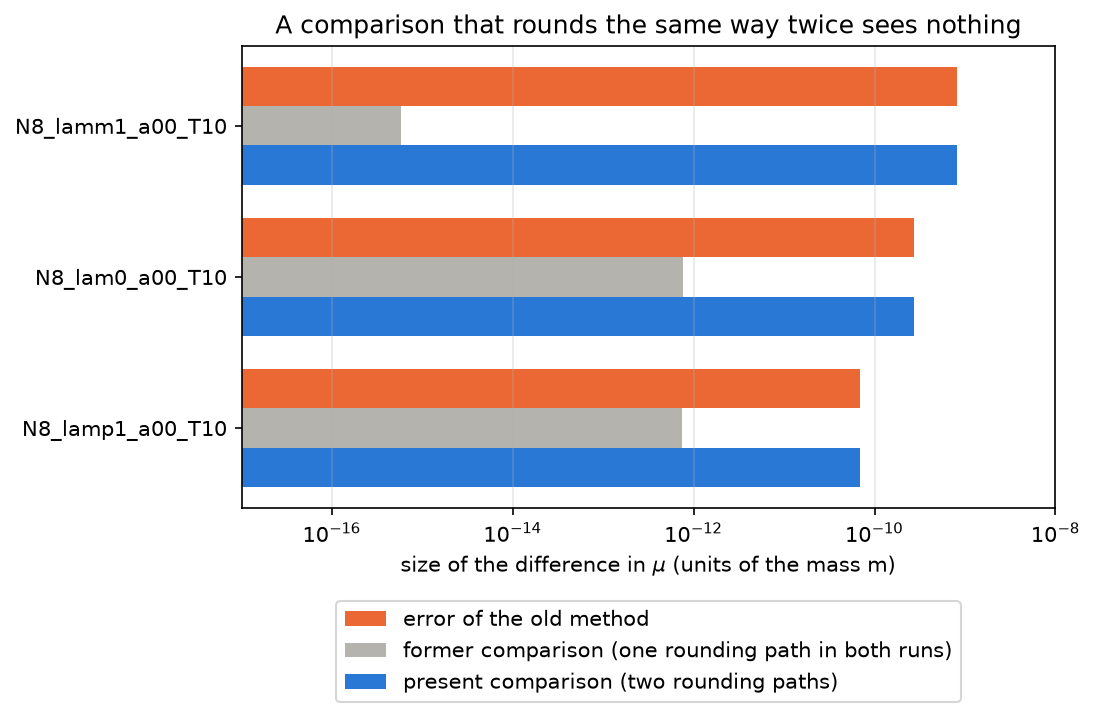

Figure 00d.4 saved as Revision/textbook/figures/00d_4_shared_rounding.png


In [10]:
fig, ax = plt.subplots(figsize=(7.0, 4.0))
rows = np.arange(len(control))[::-1]  # the first state at the top
height = 0.26  # three bars in each row
errors = [error for _, error, _, _ in control]
formers = [former for _, _, former, _ in control]
presents = [present for _, _, _, present in control]
# How many times smaller the former measure is than the error, state by state.
hidden_ratios = [error / former for error, former in zip(errors, formers)]
ax.barh(rows + height, errors, height, color=ORANGE,
        label="error of the old method")
ax.barh(rows, formers, height, color="#b5b3ad",
        label="former comparison (one rounding path in both runs)")
ax.barh(rows - height, presents, height, color=BLUE,
        label="present comparison (two rounding paths)")
ax.set_xscale("log")
ax.set_xlim(1e-17, 1e-8)
ax.set_yticks(rows, labels=[state for state, _, _, _ in control])
ax.grid(False, axis="y")
ax.set_xlabel(r"size of the difference in $\mu$ (units of the mass m)")
ax.set_title("A comparison that rounds the same way twice sees nothing")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1)
save_figure(fig, "shared_rounding",
            r"The negative control of the Revision record's Kohn-Sham solver for "
            r"the three thermal states named on the vertical axis: the error of the "
            r"old method for the chemical potential $\mu$ (orange), the difference "
            r"between the two runs when both used that method, and so shared its "
            r"rounding (grey), and the difference seen by the present refined run, "
            r"which rounds along another path (blue); horizontal axis the size of "
            r"the difference in units of the mass $m$, logarithmic. The grey bars "
            f"are between {min(hidden_ratios):.0f} and {max(hidden_ratios):.1e} "
            r"times shorter than the orange ones: two runs with the same rounding "
            f"hid errors up to {largest_hidden:.1e} "
            r"$m$, which the blue bars show in full.")

## 9. Random numbers that repeat: seeds

`np.random.default_rng(seed)` makes a random-number generator that starts from the
given seed. The next cell makes three generators, two with the seed 12345 and one
with the seed 2026, lets each produce 400 random steps of $+1$ or $-1$
(`choice([-1, 1], size=400)` picks 400 times from the list $[-1, 1]$), and adds the
steps up into random walks with `np.cumsum` (the running totals). It prints the
first ten steps of each, draws the three walks, and checks that the two walks with
the same seed are identical while the third differs.

seed 12345, first run   first steps: +1 -1 +1 -1 -1 +1 +1 +1 +1 -1
seed 12345, second run  first steps: +1 -1 +1 -1 -1 +1 +1 +1 +1 -1
seed 2026               first steps: +1 -1 -1 +1 -1 -1 -1 -1 +1 -1


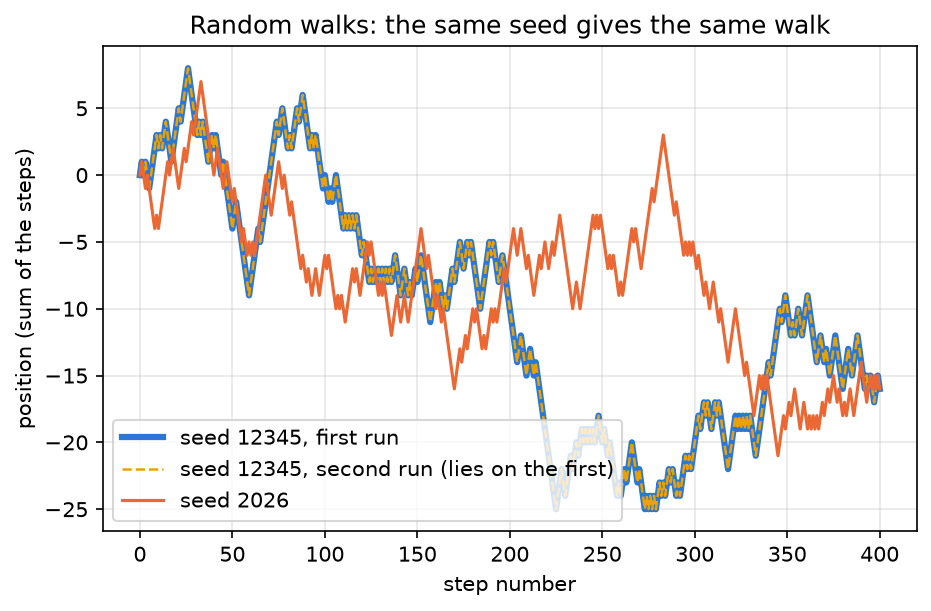

Figure 00d.5 saved as Revision/textbook/figures/00d_5_seeded_walks.png
PASS two generators with the same seed give the same 400 steps
PASS a generator with another seed gives other steps


In [11]:
walks = {}  # a label -> the 401 positions of the walk (it starts at 0)
for label, seed in (("seed 12345, first run", 12345),
                    ("seed 12345, second run", 12345), ("seed 2026", 2026)):
    generator = np.random.default_rng(seed)  # a new generator from this seed
    steps = generator.choice([-1, 1], size=400)  # 400 random steps of +1 or -1
    walks[label] = np.concatenate([[0], np.cumsum(steps)])  # positions 0 ... 400
    first = " ".join(f"{s:+d}" for s in steps[:10])  # e.g. "+1 -1 +1 ..."
    say(f"{label:23} first steps: {first}")

fig, ax = plt.subplots()
step_numbers = np.arange(401)
ax.plot(step_numbers, walks["seed 12345, first run"], color=BLUE, linewidth=3.0,
        label="seed 12345, first run")
ax.plot(step_numbers, walks["seed 12345, second run"], color=YELLOW, linewidth=1.2,
        linestyle="--", label="seed 12345, second run (lies on the first)")
ax.plot(step_numbers, walks["seed 2026"], color=ORANGE, linewidth=1.5,
        label="seed 2026")
ax.set_xlabel("step number")
ax.set_ylabel("position (sum of the steps)")
ax.set_title("Random walks: the same seed gives the same walk")
ax.legend(loc="lower left")  # the lower left corner holds no part of the walks
save_figure(fig, "seeded_walks",
            r"Three random walks of 400 steps of $+1$ or $-1$ (horizontal axis the "
            r"step number, vertical axis the position, the sum of the steps so far; "
            r"pure numbers). The thick blue walk and the dashed yellow walk come from "
            r"two separate generators started with the same seed 12345: they are "
            r"identical, step for step, so the yellow line lies on the blue one. "
            r"The orange walk, from the seed 2026, is different. A fixed seed makes "
            r"random numbers repeat exactly in every run.")
check(np.array_equal(walks["seed 12345, first run"], walks["seed 12345, second run"]),
      "two generators with the same seed give the same 400 steps")
check(not np.array_equal(walks["seed 12345, first run"], walks["seed 2026"]),
      "a generator with another seed gives other steps")

## 10. The order of a set of names

The next cell starts Python twelve times as a subprocess, each time with another
value 0, 1, ..., 11 of the environment variable PYTHONHASHSEED, and lets it print
the eight names $x_1, \ldots, x_8$ of a set. `sys.executable` is the Python program
that runs this notebook; `-c` tells it to run the program text that follows;
the names are given to that program as its arguments `sys.argv[1:]`, and
`print(*names)` prints them separated by blanks. `dict(os.environ,
PYTHONHASHSEED=...)` is a copy of the environment variables with one of them set.
The cell runs the seed 0 a second time, collects the orders, and checks three
statements: the same seed gives the same order; the twelve seeds give different
orders; and sorted with `sorted`, every order becomes $x_1, \ldots, x_8$.

This is why no notebook of the book prints a set without sorting it first: the
checking tool runs every notebook a second time with another hash seed, and an
unsorted set would print its names in another order.

In [12]:
import subprocess  # starts another program and reads what it prints

NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]
PROGRAM = "import sys; print(*set(sys.argv[1:]))"  # print the names of a set


def set_order(seed):
    """The order in which a new Python with PYTHONHASHSEED = seed prints the set."""
    environment = dict(os.environ, PYTHONHASHSEED=str(seed))
    completed = subprocess.run([sys.executable, "-c", PROGRAM, *NAMES],
                               capture_output=True, text=True, env=environment,
                               check=True)  # check=True: stop if Python failed
    return completed.stdout.split()  # the printed names, in their printed order


orders = [set_order(seed) for seed in range(12)]  # the seeds 0, 1, ..., 11
for seed, order in enumerate(orders):
    printed = " ".join(order)  # the eight names separated by blanks
    say(f"PYTHONHASHSEED={seed:<2}  {printed}")
in_order = " ".join(sorted(orders[0]))  # sorted: x1 x2 ... x8
say(f"sorted              {in_order}")
different = len({tuple(order) for order in orders})  # the number of distinct orders
report("distinct orders among the 12 runs", different)
check(set_order(0) == orders[0], "the same hash seed gives the same order")
check(different >= 2, "different hash seeds give different orders of the same set")
check(all(sorted(order) == NAMES for order in orders),
      "sorted, the names come in the same order x1 ... x8 in every run")

PYTHONHASHSEED=0   x4 x8 x6 x1 x3 x7 x2 x5
PYTHONHASHSEED=1   x8 x7 x5 x1 x3 x2 x4 x6
PYTHONHASHSEED=2   x1 x7 x2 x5 x6 x4 x8 x3
PYTHONHASHSEED=3   x5 x4 x2 x6 x3 x7 x8 x1
PYTHONHASHSEED=4   x5 x6 x7 x3 x4 x1 x2 x8
PYTHONHASHSEED=5   x1 x2 x3 x5 x7 x8 x4 x6
PYTHONHASHSEED=6   x8 x2 x7 x4 x3 x5 x1 x6
PYTHONHASHSEED=7   x1 x6 x2 x7 x5 x8 x4 x3
PYTHONHASHSEED=8   x6 x8 x5 x3 x4 x7 x1 x2
PYTHONHASHSEED=9   x3 x6 x7 x1 x8 x4 x5 x2
PYTHONHASHSEED=10  x2 x3 x5 x1 x7 x8 x6 x4
PYTHONHASHSEED=11  x5 x4 x6 x1 x3 x2 x7 x8
sorted              x1 x2 x3 x4 x5 x6 x7 x8
RESULT distinct orders among the 12 runs = 12
PASS the same hash seed gives the same order
PASS different hash seeds give different orders of the same set
PASS sorted, the names come in the same order x1 ... x8 in every run


The next cell draws the twelve orders as a picture: one row per run, one column
per place in the printed order, each square coloured by the name that stands
there; the last row is the sorted order.

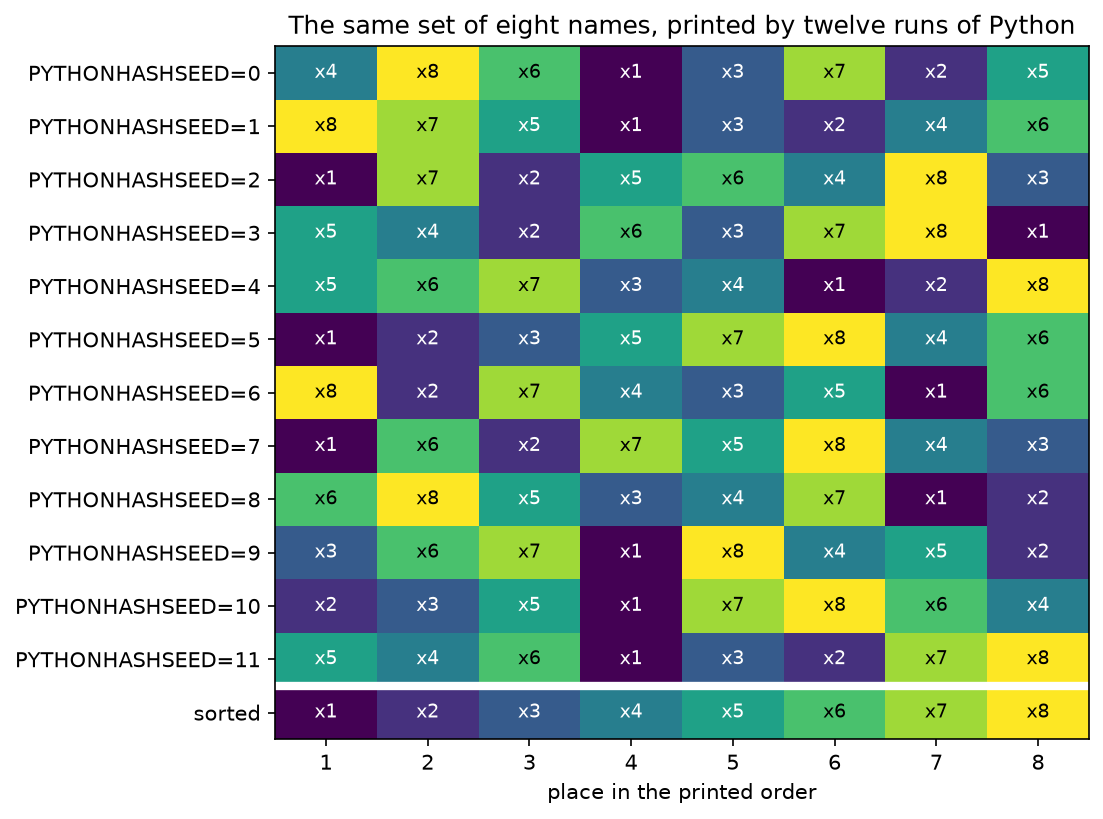

Figure 00d.6 saved as Revision/textbook/figures/00d_6_set_orders.png


In [13]:
table = orders + [sorted(orders[0])]  # 13 rows of 8 names: 12 runs and the sorted
# Each name replaced by its number in NAMES: x1 -> 0, x2 -> 1, ..., x8 -> 7.
numbers = np.array([[NAMES.index(name) for name in row] for row in table])
colours = matplotlib.colormaps["viridis"].resampled(8)  # 8 colours, violet to yellow
fig, ax = plt.subplots(figsize=(7.0, 6.0))
# vmin and vmax put each of the numbers 0 ... 7 in the middle of its own colour.
ax.imshow(numbers, cmap=colours, vmin=-0.5, vmax=7.5, aspect="auto")
for row in range(numbers.shape[0]):
    for column in range(8):
        # white letters on the dark colours, black ones on the light colours
        ink = "white" if numbers[row, column] < 5 else "black"
        ax.text(column, row, table[row][column], ha="center", va="center",
                color=ink, fontsize=9)
ax.axhline(11.5, color="white", linewidth=4.0)  # a gap before the sorted row
ax.set_xticks(range(8), labels=[str(place) for place in range(1, 9)])
ax.set_yticks(range(13),
              labels=[f"PYTHONHASHSEED={seed}" for seed in range(12)] + ["sorted"])
ax.grid(False)
ax.set_xlabel("place in the printed order")
ax.set_title("The same set of eight names, printed by twelve runs of Python")
save_figure(fig, "set_orders",
            r"The order in which twelve separate runs of Python print the same set "
            r"of the eight names $x_1, \ldots, x_8$ (one row per run, labelled by "
            r"its hash seed PYTHONHASHSEED from 0 to 11; horizontal axis the place 1 "
            r"to 8 in the printed order; each square coloured by its name, from "
            r"dark violet for $x_1$ to yellow for $x_8$). Every run prints another "
            r"order, so the rows are scrambled differently; the bottom row, the "
            r"sorted order, is the same in every run.")

## 11. Line ends

The same text can be stored with different bytes. The next cell writes the two
lines "x1 x2" and "x3 x4" as bytes, once with LF line ends and once with CR LF line
ends (`"\n"` is LF, `"\r\n"` is CR LF; `.encode("utf-8")` turns a text into
bytes), prints the bytes as numbers and their sha256 fingerprints, and checks that
the two versions have different lengths and different fingerprints. A program that
compares files byte for byte therefore needs one fixed kind of line end; the book
and the Revision record use LF everywhere. (The repository's file .gitattributes
tells git to store and deliver every file unchanged, so that a computer with
Windows receives the same LF line ends.)

In [14]:
import hashlib  # computes sha256 fingerprints

TEXT = "x1 x2\nx3 x4\n"  # two lines, each ended by a line end
with_lf = TEXT.encode("utf-8")  # LF line ends: the byte 10
with_crlf = TEXT.replace("\n", "\r\n").encode("utf-8")  # CR LF: the bytes 13, 10
for label, data in (("LF   ", with_lf), ("CR LF", with_crlf)):
    say(f"{label} {len(data):2d} bytes: {list(data)}")
    say(f"      sha256 {hashlib.sha256(data).hexdigest()}")
check(len(with_crlf) == len(with_lf) + 2
      and hashlib.sha256(with_lf).digest() != hashlib.sha256(with_crlf).digest(),
      "the same two lines with LF and with CR LF line ends are different bytes")

LF    12 bytes: [120, 49, 32, 120, 50, 10, 120, 51, 32, 120, 52, 10]
      sha256 dfcf8f120dfb5a9b8d784c7b038aa4cff5ed0b74c5809b5d51f81f763b30bf59
CR LF 14 bytes: [120, 49, 32, 120, 50, 13, 10, 120, 51, 32, 120, 52, 13, 10]
      sha256 c8b93d4c3f40882e9d91457a270e93ff4ea184e5616806b7e1b6d3ac753b52ab
PASS the same two lines with LF and with CR LF line ends are different bytes


The next cell looks at the result files of the Revision record's two Kohn-Sham
solvers: the Rust solver (the folder Revision/kohn_sham/results) and the
independent Python reference solver (the folder Revision/kohn_sham/reference/
results). For each folder it counts the files, adds up their sizes in bytes and
counts the files that contain the two bytes CR LF. The two checks require that no
file has CR LF line ends, as the record's checks `outputs_lf_only` (Rust) and
`reference_outputs_lf_only` (reference) found when the solvers ran.
`folder.rglob("*")` lists everything in a folder and in all its sub-folders;
`sorted` puts the list in a fixed order.

In [15]:
def files_below(folder):
    """The files in the repository folder and its sub-folders, in sorted order."""
    return sorted(p for p in repository_file(folder).rglob("*") if p.is_file())


RUST_RESULTS = "Revision/kohn_sham/results"
REFERENCE_RESULTS = "Revision/kohn_sham/reference/results"
rust_files = files_below(RUST_RESULTS)
rust_crlf = sum(1 for p in rust_files if b"\r\n" in p.read_bytes())
reference_files = files_below(REFERENCE_RESULTS)
reference_crlf = sum(1 for p in reference_files if b"\r\n" in p.read_bytes())
report("Rust result files", len(rust_files))
report("size of the Rust result files", sum(p.stat().st_size for p in rust_files),
       "bytes")
report("Rust result files with CR LF line ends", rust_crlf)
report("reference result files", len(reference_files))
report("size of the reference result files",
       sum(p.stat().st_size for p in reference_files), "bytes")
report("reference result files with CR LF line ends", reference_crlf)

lf_rust = determinism_checks["outputs_lf_only"]  # the record's check (Rust)
check_reproduces(
    rust_crlf == 0 and lf_rust["verdict"] == "PASS"
    and "(offending: none)" in lf_rust["detail"],
    f"none of the {len(rust_files)} Rust result files has CR LF line ends",
    f"{DETERMINISM}, check outputs_lf_only")
cross_checks = {entry["name"]: entry for entry in read_json(CROSS)["checks"]}
lf_reference = cross_checks["reference_outputs_lf_only"]  # the record's check
stated = f"{len(reference_files)} reference result files; files with CRLF: none"
check_reproduces(
    reference_crlf == 0 and lf_reference["verdict"] == "PASS"
    and stated in lf_reference["detail"],
    f"none of the {len(reference_files)} reference result files has CR LF line ends",
    f"{CROSS}, check reference_outputs_lf_only")

RESULT Rust result files = 244
RESULT size of the Rust result files = 5857791 bytes
RESULT Rust result files with CR LF line ends = 0
RESULT reference result files = 340
RESULT size of the reference result files = 24125750 bytes
RESULT reference result files with CR LF line ends = 0
PASS none of the 244 Rust result files has CR LF line ends
     reproduces Revision/kohn_sham/reports/ks-rust-determinism.json, check
    outputs_lf_only
PASS none of the 340 reference result files has CR LF line ends
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    reference_outputs_lf_only


## 12. Fingerprints of the result files

Each of the two result folders holds a manifest, a file manifest.json that lists
every other file of the folder with its sha256 fingerprint: the Rust solver's
manifest gives for each file its path, its size and its fingerprint; the reference
solver's manifest gives for each path its fingerprint. The next cell computes the
fingerprint of every listed file as it is today, compares it with the listed one,
and checks that every file of each folder except the manifest itself is listed.
When all agree, the files of today are exactly, byte for byte, the files that the
solvers wrote.

The record also ran each solver a second time and compared every file of the two
runs: the Rust solver in the check `repeat_byte_identical` of the report
ks-rust-determinism.json ("244 files (... bytes) compared"), the reference solver
in the check `reference_repeat_byte_identical` of the cross-check report. The last
two checks of the cell confirm that the record found no differing file and that it
compared as many files (and, for the Rust solver, as many bytes) as the folders
hold today.

In [16]:
def file_fingerprint(path):
    """The sha256 fingerprint of the bytes of the file path."""
    return hashlib.sha256(path.read_bytes()).hexdigest()


def relative_names(files, folder):
    """The paths of files relative to the repository folder, written with /."""
    root = repository_file(folder)
    return sorted(p.relative_to(root).as_posix() for p in files)


# The Rust manifest: a list of entries {"path": ..., "bytes": ..., "sha256": ...}.
rust_manifest = read_json(f"{RUST_RESULTS}/manifest.json")["files"]
rust_listed = {entry["path"]: entry for entry in rust_manifest}  # path -> entry
rust_wrong = []  # the listed files whose size or fingerprint differs today
for path, entry in rust_listed.items():
    today = repository_file(f"{RUST_RESULTS}/{path}")  # the file as it is today
    same_size = today.stat().st_size == entry["bytes"]
    if not same_size or file_fingerprint(today) != entry["sha256"]:
        rust_wrong.append(path)
# The reference manifest: a dictionary path -> fingerprint.
reference_manifest = read_json(f"{REFERENCE_RESULTS}/manifest.json")["files"]
reference_wrong = []
for path, value in reference_manifest.items():
    today = repository_file(f"{REFERENCE_RESULTS}/{path}")
    if file_fingerprint(today) != value:
        reference_wrong.append(path)
report("Rust results: fingerprints compared", len(rust_listed))
report("Rust results: files that differ", len(rust_wrong))
report("reference results: fingerprints compared", len(reference_manifest))
report("reference results: files that differ", len(reference_wrong))
report("fingerprints compared in all", len(rust_listed) + len(reference_manifest))
rust_others = [n for n in relative_names(rust_files, RUST_RESULTS)
               if n != "manifest.json"]
reference_others = [n for n in relative_names(reference_files, REFERENCE_RESULTS)
                    if n != "manifest.json"]
check(rust_wrong == [] and sorted(rust_listed) == rust_others,
      f"the {len(rust_listed)} fingerprints of the Rust manifest equal today's files")
manifest_check = cross_checks["reference_manifest"]
stated = f"lists {len(reference_manifest)} files with SHA-256"  # the record's words
check_reproduces(
    reference_wrong == [] and sorted(reference_manifest) == reference_others
    and manifest_check["verdict"] == "PASS" and stated in manifest_check["detail"],
    f"the {len(reference_manifest)} fingerprints of the reference manifest equal "
    "today's files",
    f"{CROSS}, check reference_manifest")
rust_repeat = determinism_checks["repeat_byte_identical"]  # the Rust second run
# The part of its detail that counts, e.g. "244 files (5857791 bytes) compared, ...".
found = re.search(r"(\d+) files \((\d+) bytes\) compared, same file set: (\w+), "
                  r"differing files: (\w+)", rust_repeat["detail"])
say(f"the record (Rust): {found.group(0)}")
rust_bytes = sum(p.stat().st_size for p in rust_files)  # the bytes of today
check_reproduces(
    rust_repeat["verdict"] == "PASS"
    and (int(found.group(1)), int(found.group(2))) == (len(rust_files), rust_bytes)
    and found.group(3) == "True" and found.group(4) == "none",
    f"a second run of the Rust solver gave the same {len(rust_files)} files "
    f"({rust_bytes} bytes)",
    f"{DETERMINISM}, check repeat_byte_identical")
repeat = cross_checks["reference_repeat_byte_identical"]  # the reference second run
# The part of its detail that counts the files, e.g. "340 result files, same ...".
found = re.search(r"(\d+) result files, same file set: (\w+), differing files: (\w+)",
                  repeat["detail"])
say(f"the record (reference): {found.group(0)}")
check_reproduces(
    repeat["verdict"] == "PASS" and int(found.group(1)) == len(reference_files)
    and found.group(2) == "True" and found.group(3) == "none",
    f"a second run of the reference solver gave the same {len(reference_files)} "
    "files, byte for byte",
    f"{CROSS}, check reference_repeat_byte_identical")

RESULT Rust results: fingerprints compared = 243
RESULT Rust results: files that differ = 0
RESULT reference results: fingerprints compared = 339
RESULT reference results: files that differ = 0
RESULT fingerprints compared in all = 582
PASS the 243 fingerprints of the Rust manifest equal today's files
PASS the 339 fingerprints of the reference manifest equal today's files
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check reference_manifest
the record (Rust): 244 files (5857791 bytes) compared, same file set: True, differing
    files: none
PASS a second run of the Rust solver gave the same 244 files (5857791 bytes)
     reproduces Revision/kohn_sham/reports/ks-rust-determinism.json, check
    repeat_byte_identical
the record (reference): 340 result files, same file set: True, differing files: none
PASS a second run of the reference solver gave the same 340 files, byte for byte
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    reference_repeat_b

## 13. The last check

The last cell checks that the six figure files of this notebook exist in the
folder Revision/textbook/figures and prints the number of checks that passed.

In [17]:
figure_names = ["00d_1_float_spacing.png", "00d_2_summation_order.png",
                "00d_3_tolerances.png", "00d_4_shared_rounding.png",
                "00d_5_seeded_walks.png", "00d_6_set_orders.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "the six figure files of this notebook exist")
all_checks_passed()

PASS the six figure files of this notebook exist
ALL 22 CHECKS PASSED (notebook 00d)


## 14. What this notebook showed

- The computer stores numbers as binary fractions with 53 significant binary
  digits: 0.1 is stored as $3602879701896397/2^{55}$, and $0.1 + 0.2$ differs from
  $0.3$ by one rounding step, $2^{-54}$. The gap between neighbouring stored
  numbers grows with their size and always lies between $\epsilon x/2$ and
  $\epsilon x$, $\epsilon = 2^{-52}$.
- Rounding is deterministic, but it depends on the order of the operations: the
  same million numbers added forwards and backwards give sums that differ by
  about 200 units in the last place, a relative difference of a few times
  $10^{-14}$. This is why every comparison of two different computations uses a
  tolerance, fixed in advance.
- The Revision record's Kohn-Sham solver was compared with a refined run of itself:
  all eight measured differences lie below the tolerances that were fixed in
  advance (the margins are printed in section 8). The record's negative control
  shows that two runs with the same rounding path hid errors of the chemical
  potential up to about $8 \times 10^{-10}\,m$, which is why the refined run now
  rounds along a different path.
- A fixed seed makes random numbers repeat exactly; the order of a set of names
  changes with the hash seed, while the sorted order does not; LF and CR LF line
  ends make the same text into different bytes.
- The result files of the record's two Kohn-Sham solvers have only LF line ends,
  and the 582 fingerprints of their two manifests equal the files of today: the
  stored results are exactly the ones the solvers wrote. A second run of each
  solver gave the same files byte for byte.